# Modeling (Allen Ros)

Using Nutrition Information to Classify Brand Tier (Premium Foods)

Mia Arnold - Jordan Blackman - Allen Ros

Shirley Marcos School of Engineering, University of San Diego

ADS-502 Applied Data Mining

# Goals

1. Data type transformation, remove features that would lead to overfitting, test train split, SMOTENC(nominal and continuous), Encoding, and Scaling.

2. Establish Baseline Model and evaluation metrics

3. Train initial models, tune hyperparameters (max leaf, minobservations, C for regularization), explore cost matrices, and explore bagging and boosting

4. Compare all models across multiple metrics beyond accuracy

Models to explore: Baseline (Majority Class), Naive Bayes, SVC (Linear), SVC (RBF), SVC (Polynomial), SVC (Sigmoid).

# Data Type Transformation and Removing Overfitting Features

In [1]:
# import the necessary packages
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv("food_menu_nutrition_dataset.csv")

# log price, protein, and sugars to handle significant skew
df['log_price_usd_normalized'] = np.log1p(df['price_usd_normalized'])
df['log_protein_g'] = np.log1p(df['protein_g'])
df['log_sugars_g'] = np.log1p(df['sugars_g'])

# square root serving size, calories, fat, carbs, sodium to handle small skew
df['sqrt_serving_size_g'] = np.sqrt(df['serving_size_g'])
df['sqrt_calories'] = np.sqrt(df['calories'])
df['sqrt_total_fat_g'] = np.sqrt(df['total_fat_g'])
df['sqrt_total_carbs_g'] = np.sqrt(df['total_carbs_g'])
df['sqrt_sodium_mg'] = np.sqrt(df['sodium_mg'])

# flip average rating to handle left skew, units are flipped
# reflect constant is the max rating (5) + 1 so data leakage is not introduced with new data
reflect_constant = 5 + 1
df['trans_avg_rating'] = np.sqrt(reflect_constant - df['avg_rating'])

# is_bestseller is the only numerical variable left alone

# drop all original columns that were transformed
df = df.drop(columns=['price_usd_normalized', 'protein_g', 'sugars_g',
                      'serving_size_g', 'calories', 'total_fat_g',
                      'total_carbs_g', 'sodium_mg', 'avg_rating'])

# set up items that are not being used for training models
items_to_drop = ['item_name', 'city', 'brand_name',
                 'brand_tier']

# get dependent and independent variables
Y = (df['brand_tier'] == 'premium').astype(int)
X = df.drop(columns=items_to_drop)

# view the data
df.head().T

,0,1,2,3,4
item_name,Veggie Sub,Waffles with Syrup,Grilled Chicken Salad,Waffles with Syrup,Chocolate Brownie
item_category,Sandwich,Dessert,Salad,Dessert,Dessert
item_subcategory,Veg,Veg,Non-Veg,Veg,Veg
brand_name,Five Guys,KFC,Domino's,Five Guys,Subway
brand_tier,mid,budget,budget,mid,budget
country,UK,USA,Canada,USA,USA
city,London,Austin,Toronto,Chicago,Chicago
city_tier,metro,tier-2,metro,metro,metro
is_bestseller,0,0,0,0,0
log_price_usd_normalized,2.267994,1.329724,1.912501,2.248129,1.332366


# Test Train Split

In [2]:
# test train split with random state and stratification
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y)

# SMOTE

In [3]:
# Oversample the minority class (Premium)
from imblearn.over_sampling import SMOTENC

cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.drop(
    items_to_drop, errors='ignore').tolist()

cat_indices = [X_train.columns.get_loc(col) for col in cat_cols]

print("Before SMOTE")
print(Y_train.value_counts())

smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)
X_train, Y_train = smote_nc.fit_resample(X_train, Y_train)

print("After SMOTE:")
print(Y_train.value_counts())

Before SMOTE
brand_tier
0    5404
1     596
Name: count, dtype: int64
After SMOTE:
brand_tier
0    5404
1    5404
Name: count, dtype: int64


# Encoding

In [4]:
# encode variables
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# align encoded variables
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns, fill_value=0)

# Scaling

In [5]:
from sklearn.preprocessing import StandardScaler

# scale variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# Establish Evaluation Function

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# define a reusable function to calculate evaluation metrics for all models


def evaluate_model(y_true, y_pred, y_prob=None, model_name="Model", verbose=True):

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    roc_auc = None
    if y_prob is not None:
        roc_auc = roc_auc_score(y_true, y_prob)

    if verbose:
        print(f"--- {model_name} Evaluation ---")
        print(f"Accuracy:    {acc:.4f}")
        print(f"Precision:   {prec:.4f}")
        print(f"Recall:      {rec:.4f} (Sensitivity)")
        print(f"Specificity: {specificity:.4f}")
        print(f"F1-Score:    {f1:.4f}")

        if roc_auc is not None:
            print(f"ROC AUC:     {roc_auc:.4f}")

        print("-" * 30 + "\n")

        fig, ax = plt.subplots(figsize=(4, 4))
        ConfusionMatrixDisplay.from_predictions(
            y_true, y_pred, ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f"Confusion Matrix: {model_name}")
        plt.tight_layout()
        plt.show()

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "specificity": specificity,
        "f1_score": f1,
        "roc_auc": roc_auc
    }

# Establish Reusable Modeling Function

In [7]:
# establish a function trains and evaluates all models
def train_and_evaluate(model, x_train, y_train, x_test, y_test, model_name, verbose=True):

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    y_prob = None
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(x_test)[:, 1]

    metrics = evaluate_model(y_test, y_pred, y_prob, model_name, verbose)

    return metrics

# Establish Baseline Model

--- Baseline (Majority Class) Evaluation ---
Accuracy:    0.9007
Precision:   0.0000
Recall:      0.0000 (Sensitivity)
Specificity: 1.0000
F1-Score:    0.0000
ROC AUC:     0.5000
------------------------------



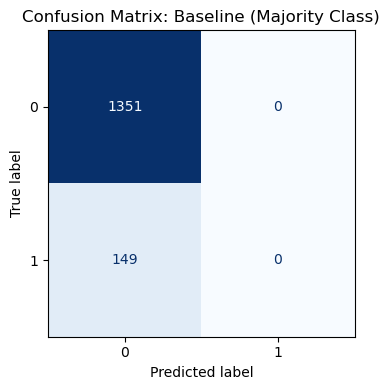

In [8]:
# dummy model always predicts the majority class
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="constant", constant=0)

baseline_metrics = train_and_evaluate(
    baseline,
    X_train,
    Y_train,
    X_test,
    Y_test,
    model_name="Baseline (Majority Class)"
)

# Train Initial Models

--- Naive Bayes 1 Evaluation ---
Accuracy:    0.8227
Precision:   0.3107
Recall:      0.6443 (Sensitivity)
Specificity: 0.8423
F1-Score:    0.4192
ROC AUC:     0.8071
------------------------------



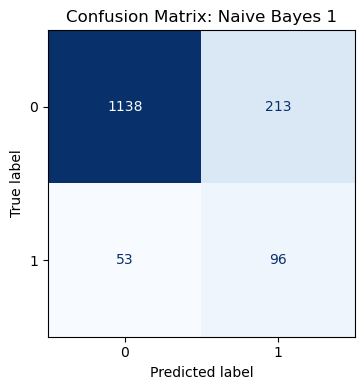

In [9]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb_1 = GaussianNB()

nb_1_metrics = train_and_evaluate(
    nb_1,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="Naive Bayes 1"
)

# Train SVC Models

--- SVC Linear C=0.001 Evaluation ---
Accuracy:    0.9100
Precision:   0.5278
Recall:      0.8926 (Sensitivity)
Specificity: 0.9119
F1-Score:    0.6633
ROC AUC:     0.9732
------------------------------



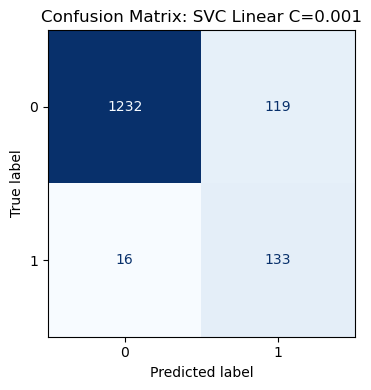

--- SVC Linear C=0.01 Evaluation ---
Accuracy:    0.9153
Precision:   0.5451
Recall:      0.8926 (Sensitivity)
Specificity: 0.9178
F1-Score:    0.6768
ROC AUC:     0.9772
------------------------------



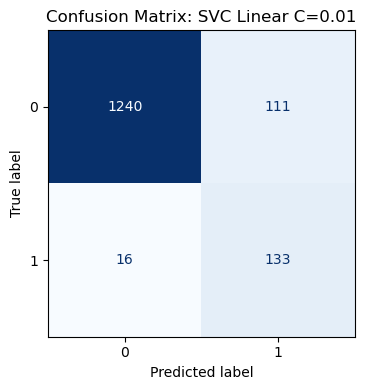

--- SVC Linear C=0.1 Evaluation ---
Accuracy:    0.9140
Precision:   0.5400
Recall:      0.9060 (Sensitivity)
Specificity: 0.9149
F1-Score:    0.6767
ROC AUC:     0.9809
------------------------------



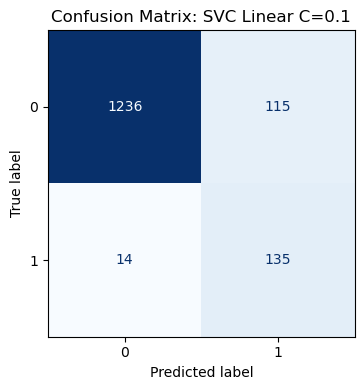

--- SVC Linear C=0.2 Evaluation ---
Accuracy:    0.9160
Precision:   0.5458
Recall:      0.9195 (Sensitivity)
Specificity: 0.9156
F1-Score:    0.6850
ROC AUC:     0.9815
------------------------------



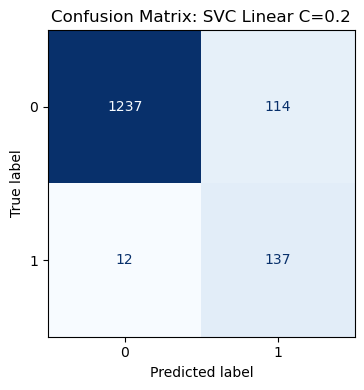

--- SVC Linear C=0.5 Evaluation ---
Accuracy:    0.9140
Precision:   0.5391
Recall:      0.9262 (Sensitivity)
Specificity: 0.9127
F1-Score:    0.6815
ROC AUC:     0.9818
------------------------------



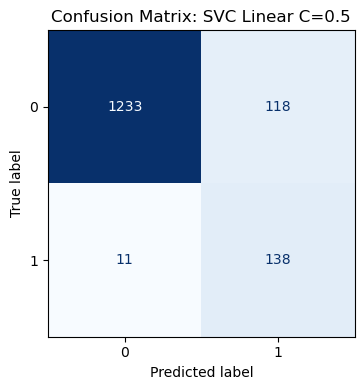

--- SVC Linear C=0.8 Evaluation ---
Accuracy:    0.9133
Precision:   0.5370
Recall:      0.9262 (Sensitivity)
Specificity: 0.9119
F1-Score:    0.6798
ROC AUC:     0.9819
------------------------------



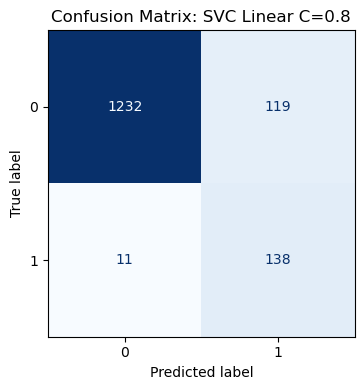

--- SVC Linear C=1 Evaluation ---
Accuracy:    0.9140
Precision:   0.5391
Recall:      0.9262 (Sensitivity)
Specificity: 0.9127
F1-Score:    0.6815
ROC AUC:     0.9818
------------------------------



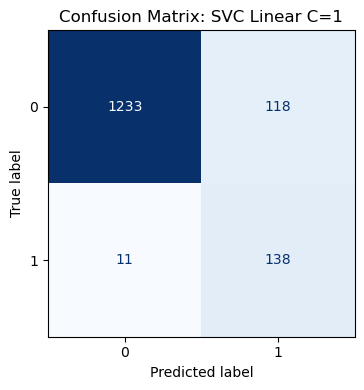

--- SVC Linear C=5 Evaluation ---
Accuracy:    0.9140
Precision:   0.5388
Recall:      0.9329 (Sensitivity)
Specificity: 0.9119
F1-Score:    0.6830
ROC AUC:     0.9819
------------------------------



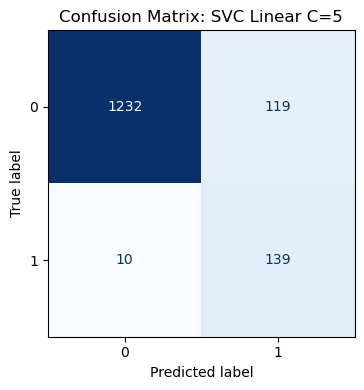

--- SVC Linear C=10 Evaluation ---
Accuracy:    0.9140
Precision:   0.5388
Recall:      0.9329 (Sensitivity)
Specificity: 0.9119
F1-Score:    0.6830
ROC AUC:     0.9819
------------------------------



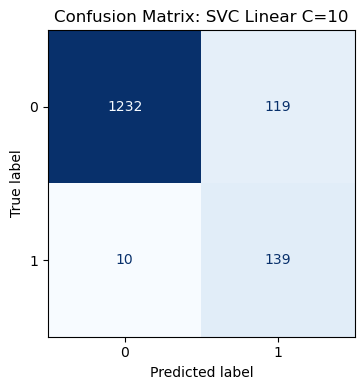

--- SVC Linear C=20 Evaluation ---
Accuracy:    0.9140
Precision:   0.5388
Recall:      0.9329 (Sensitivity)
Specificity: 0.9119
F1-Score:    0.6830
ROC AUC:     0.9819
------------------------------



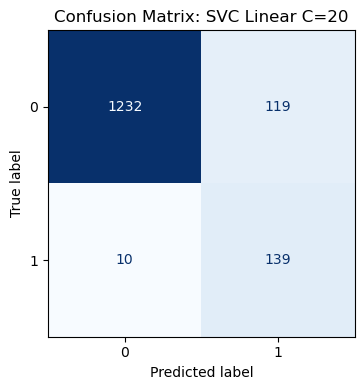

--- SVC Linear C=50 Evaluation ---
Accuracy:    0.9140
Precision:   0.5388
Recall:      0.9329 (Sensitivity)
Specificity: 0.9119
F1-Score:    0.6830
ROC AUC:     0.9819
------------------------------



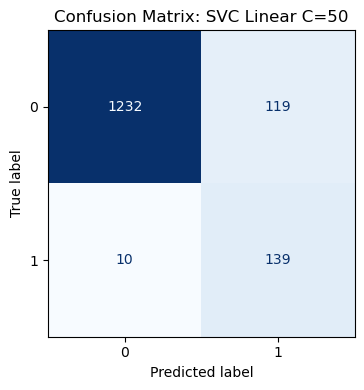

--- SVC RBF C=0.001 Evaluation ---
Accuracy:    0.8507
Precision:   0.3404
Recall:      0.5369 (Sensitivity)
Specificity: 0.8853
F1-Score:    0.4167
ROC AUC:     0.8465
------------------------------



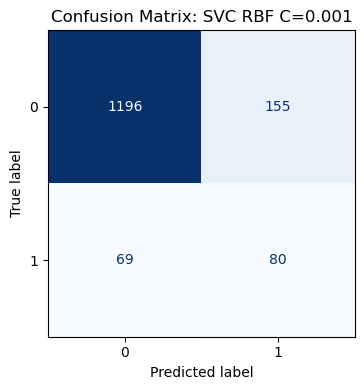

--- SVC RBF C=0.01 Evaluation ---
Accuracy:    0.8787
Precision:   0.4358
Recall:      0.7517 (Sensitivity)
Specificity: 0.8927
F1-Score:    0.5517
ROC AUC:     0.9253
------------------------------



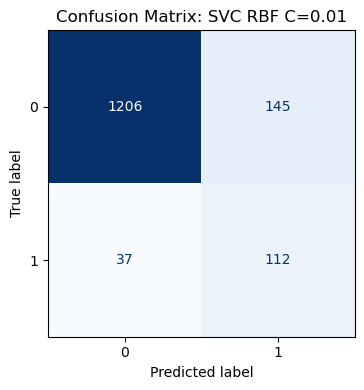

--- SVC RBF C=0.1 Evaluation ---
Accuracy:    0.9167
Precision:   0.5561
Recall:      0.7987 (Sensitivity)
Specificity: 0.9297
F1-Score:    0.6556
ROC AUC:     0.9635
------------------------------



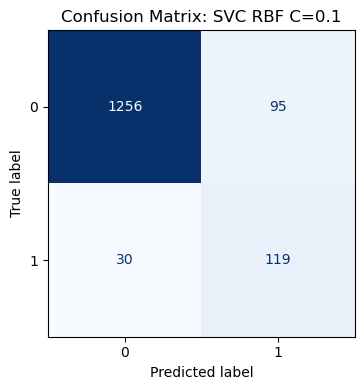

--- SVC RBF C=0.2 Evaluation ---
Accuracy:    0.9173
Precision:   0.5592
Recall:      0.7919 (Sensitivity)
Specificity: 0.9312
F1-Score:    0.6556
ROC AUC:     0.9667
------------------------------



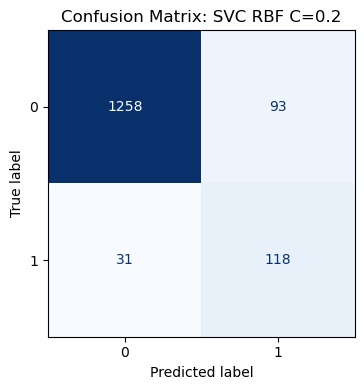

--- SVC RBF C=0.5 Evaluation ---
Accuracy:    0.9240
Precision:   0.5862
Recall:      0.7987 (Sensitivity)
Specificity: 0.9378
F1-Score:    0.6761
ROC AUC:     0.9683
------------------------------



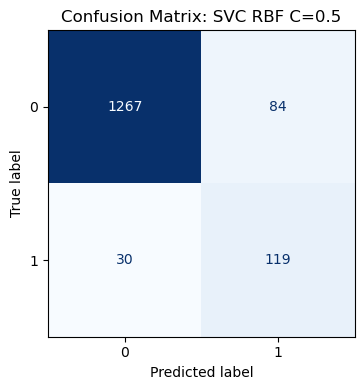

--- SVC RBF C=0.8 Evaluation ---
Accuracy:    0.9273
Precision:   0.5990
Recall:      0.8121 (Sensitivity)
Specificity: 0.9400
F1-Score:    0.6895
ROC AUC:     0.9695
------------------------------



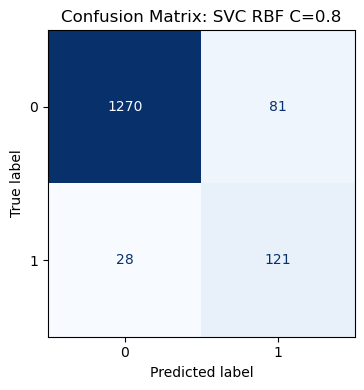

--- SVC RBF C=1 Evaluation ---
Accuracy:    0.9293
Precision:   0.6070
Recall:      0.8188 (Sensitivity)
Specificity: 0.9415
F1-Score:    0.6971
ROC AUC:     0.9698
------------------------------



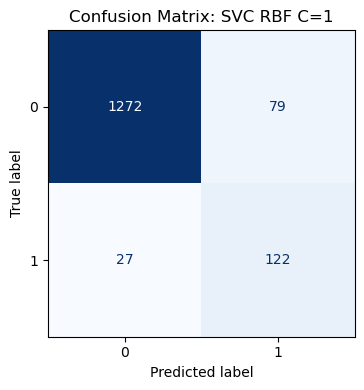

--- SVC RBF C=5 Evaluation ---
Accuracy:    0.9313
Precision:   0.6186
Recall:      0.8054 (Sensitivity)
Specificity: 0.9452
F1-Score:    0.6997
ROC AUC:     0.9679
------------------------------



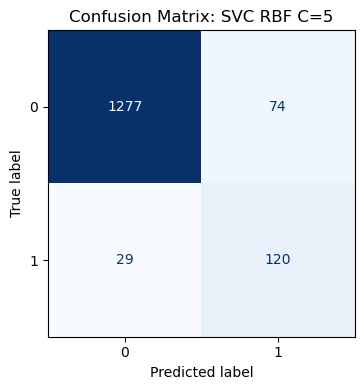

--- SVC RBF C=10 Evaluation ---
Accuracy:    0.9307
Precision:   0.6203
Recall:      0.7785 (Sensitivity)
Specificity: 0.9474
F1-Score:    0.6905
ROC AUC:     0.9650
------------------------------



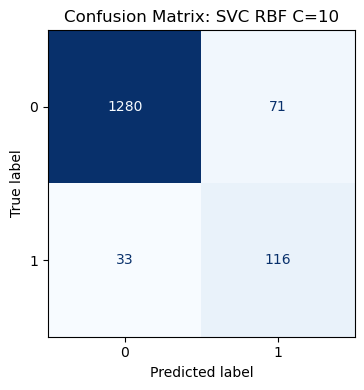

--- SVC RBF C=20 Evaluation ---
Accuracy:    0.9240
Precision:   0.5946
Recall:      0.7383 (Sensitivity)
Specificity: 0.9445
F1-Score:    0.6587
ROC AUC:     0.9592
------------------------------



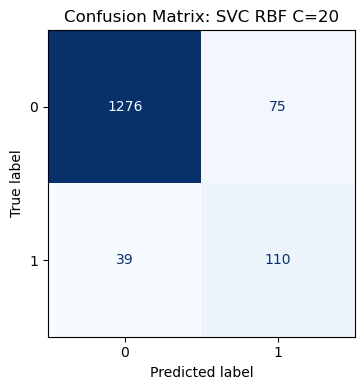

--- SVC RBF C=50 Evaluation ---
Accuracy:    0.9220
Precision:   0.5870
Recall:      0.7248 (Sensitivity)
Specificity: 0.9437
F1-Score:    0.6486
ROC AUC:     0.9492
------------------------------



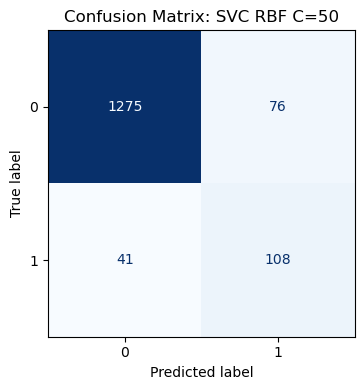

--- SVC Poly C=0.001 Evaluation ---
Accuracy:    0.3867
Precision:   0.1318
Recall:      0.9262 (Sensitivity)
Specificity: 0.3272
F1-Score:    0.2308
ROC AUC:     0.8457
------------------------------



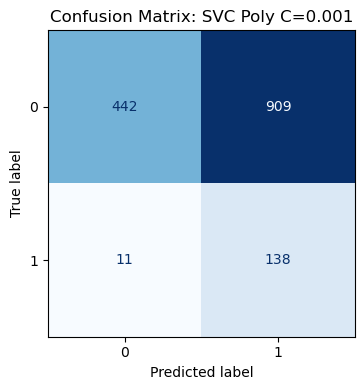

--- SVC Poly C=0.01 Evaluation ---
Accuracy:    0.8987
Precision:   0.4929
Recall:      0.6980 (Sensitivity)
Specificity: 0.9208
F1-Score:    0.5778
ROC AUC:     0.9049
------------------------------



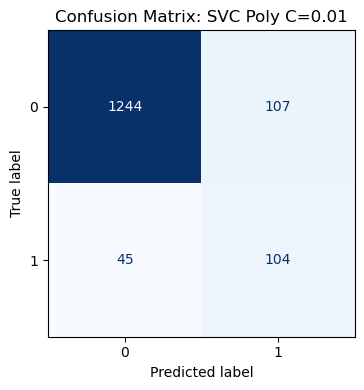

--- SVC Poly C=0.1 Evaluation ---
Accuracy:    0.9267
Precision:   0.5933
Recall:      0.8322 (Sensitivity)
Specificity: 0.9371
F1-Score:    0.6927
ROC AUC:     0.9699
------------------------------



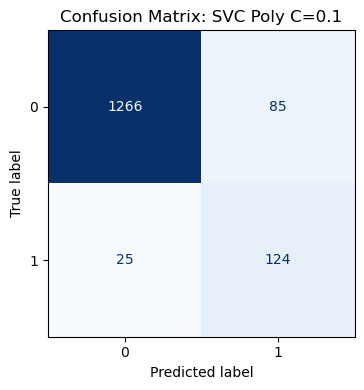

--- SVC Poly C=0.2 Evaluation ---
Accuracy:    0.9273
Precision:   0.5926
Recall:      0.8591 (Sensitivity)
Specificity: 0.9349
F1-Score:    0.7014
ROC AUC:     0.9718
------------------------------



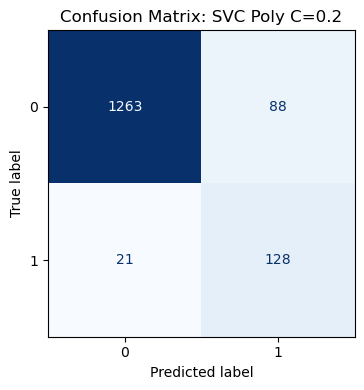

--- SVC Poly C=0.5 Evaluation ---
Accuracy:    0.9280
Precision:   0.5972
Recall:      0.8456 (Sensitivity)
Specificity: 0.9371
F1-Score:    0.7000
ROC AUC:     0.9713
------------------------------



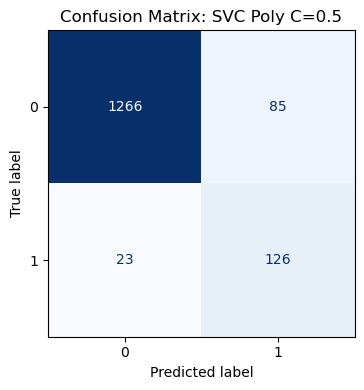

--- SVC Poly C=0.8 Evaluation ---
Accuracy:    0.9307
Precision:   0.6087
Recall:      0.8456 (Sensitivity)
Specificity: 0.9400
F1-Score:    0.7079
ROC AUC:     0.9710
------------------------------



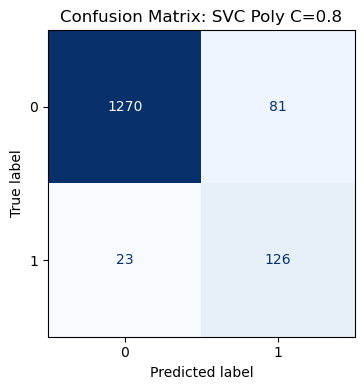

--- SVC Poly C=1 Evaluation ---
Accuracy:    0.9300
Precision:   0.6058
Recall:      0.8456 (Sensitivity)
Specificity: 0.9393
F1-Score:    0.7059
ROC AUC:     0.9712
------------------------------



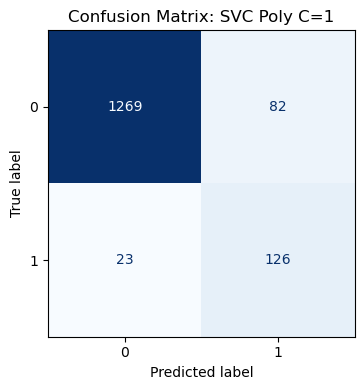

--- SVC Poly C=5 Evaluation ---
Accuracy:    0.9200
Precision:   0.5674
Recall:      0.8188 (Sensitivity)
Specificity: 0.9312
F1-Score:    0.6703
ROC AUC:     0.9646
------------------------------



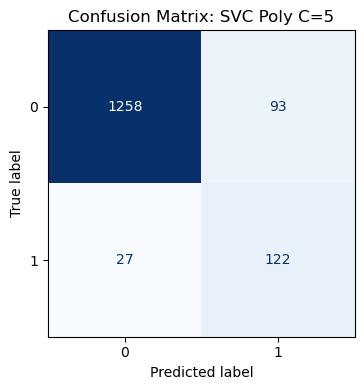

--- SVC Poly C=10 Evaluation ---
Accuracy:    0.9147
Precision:   0.5488
Recall:      0.7919 (Sensitivity)
Specificity: 0.9282
F1-Score:    0.6484
ROC AUC:     0.9591
------------------------------



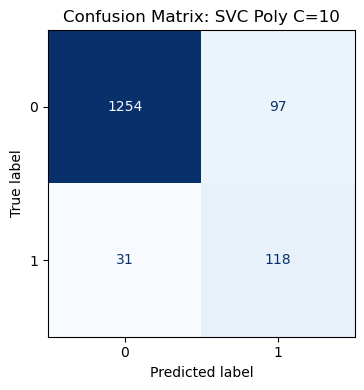

--- SVC Poly C=20 Evaluation ---
Accuracy:    0.9107
Precision:   0.5336
Recall:      0.7987 (Sensitivity)
Specificity: 0.9230
F1-Score:    0.6398
ROC AUC:     0.9514
------------------------------



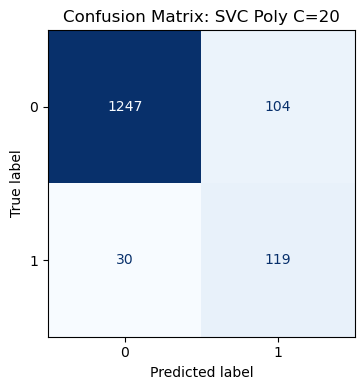

--- SVC Poly C=50 Evaluation ---
Accuracy:    0.9027
Precision:   0.5067
Recall:      0.7651 (Sensitivity)
Specificity: 0.9178
F1-Score:    0.6096
ROC AUC:     0.9399
------------------------------



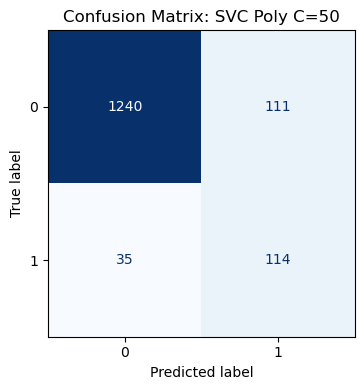

--- SVC Sigmoid C=0.001 Evaluation ---
Accuracy:    0.8393
Precision:   0.3589
Recall:      0.7852 (Sensitivity)
Specificity: 0.8453
F1-Score:    0.4926
ROC AUC:     0.8969
------------------------------



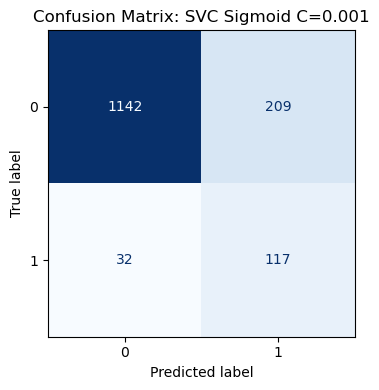

--- SVC Sigmoid C=0.01 Evaluation ---
Accuracy:    0.9020
Precision:   0.5039
Recall:      0.8725 (Sensitivity)
Specificity: 0.9053
F1-Score:    0.6388
ROC AUC:     0.9676
------------------------------



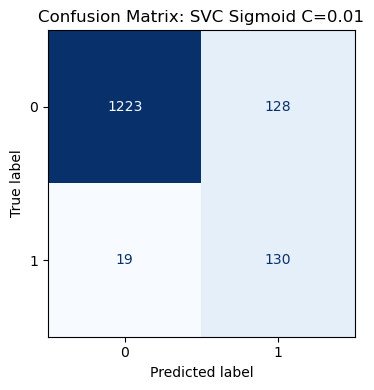

--- SVC Sigmoid C=0.1 Evaluation ---
Accuracy:    0.8480
Precision:   0.3814
Recall:      0.8523 (Sensitivity)
Specificity: 0.8475
F1-Score:    0.5270
ROC AUC:     0.9333
------------------------------



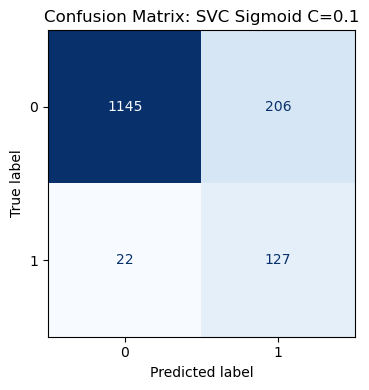

--- SVC Sigmoid C=0.2 Evaluation ---
Accuracy:    0.8387
Precision:   0.3644
Recall:      0.8389 (Sensitivity)
Specificity: 0.8386
F1-Score:    0.5081
ROC AUC:     0.9126
------------------------------



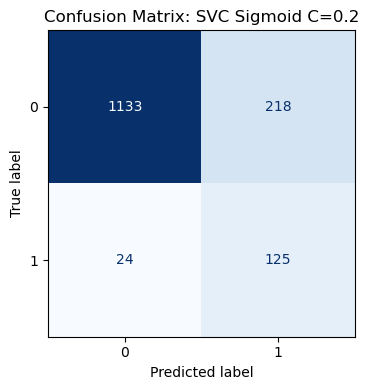

--- SVC Sigmoid C=0.5 Evaluation ---
Accuracy:    0.8273
Precision:   0.3455
Recall:      0.8255 (Sensitivity)
Specificity: 0.8275
F1-Score:    0.4871
ROC AUC:     0.9018
------------------------------



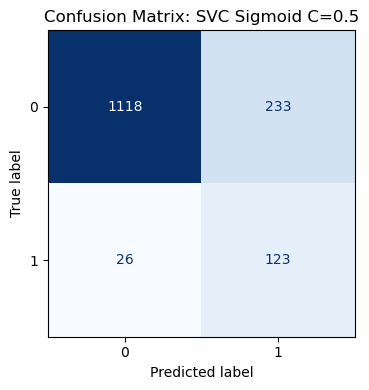

--- SVC Sigmoid C=0.8 Evaluation ---
Accuracy:    0.8300
Precision:   0.3486
Recall:      0.8188 (Sensitivity)
Specificity: 0.8312
F1-Score:    0.4890
ROC AUC:     0.8956
------------------------------



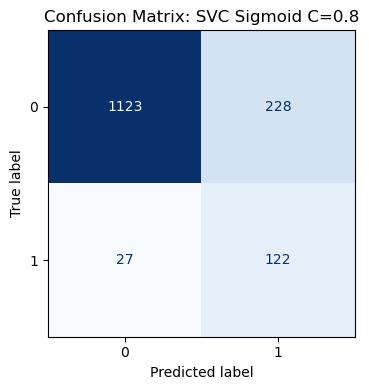

--- SVC Sigmoid C=1 Evaluation ---
Accuracy:    0.8300
Precision:   0.3494
Recall:      0.8255 (Sensitivity)
Specificity: 0.8305
F1-Score:    0.4910
ROC AUC:     0.8940
------------------------------



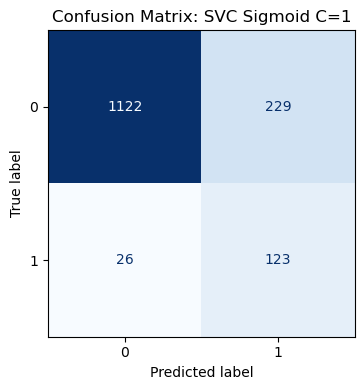

--- SVC Sigmoid C=5 Evaluation ---
Accuracy:    0.8280
Precision:   0.3420
Recall:      0.7919 (Sensitivity)
Specificity: 0.8320
F1-Score:    0.4777
ROC AUC:     0.8879
------------------------------



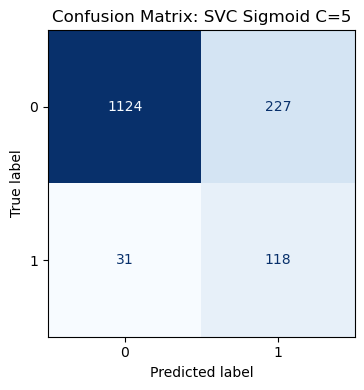

--- SVC Sigmoid C=10 Evaluation ---
Accuracy:    0.8287
Precision:   0.3430
Recall:      0.7919 (Sensitivity)
Specificity: 0.8327
F1-Score:    0.4787
ROC AUC:     0.8875
------------------------------



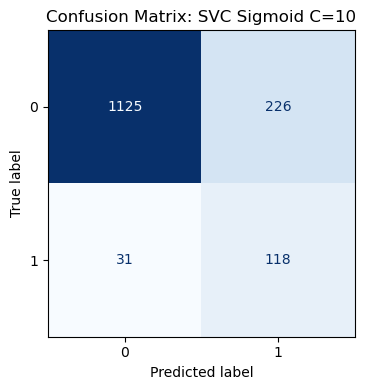

--- SVC Sigmoid C=20 Evaluation ---
Accuracy:    0.8280
Precision:   0.3411
Recall:      0.7852 (Sensitivity)
Specificity: 0.8327
F1-Score:    0.4756
ROC AUC:     0.8861
------------------------------



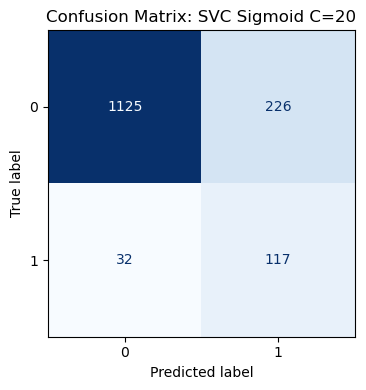

--- SVC Sigmoid C=50 Evaluation ---
Accuracy:    0.8280
Precision:   0.3411
Recall:      0.7852 (Sensitivity)
Specificity: 0.8327
F1-Score:    0.4756
ROC AUC:     0.8856
------------------------------



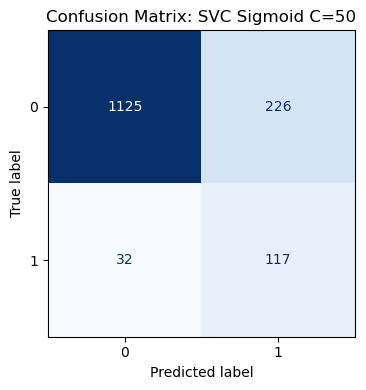

In [10]:
#SVC Modeling

from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

C = [0.001, 0.01, 0.1, 0.2, 0.5, 0.8, 1, 5, 10, 20, 50]
svc_kernels = ["Linear", "RBF", "Poly", "Sigmoid"]

# svc_tuning = []

# Compare all model results
model_results = [val for name, val in globals().items(
) if 'metrics' in name and isinstance(val, dict)]


# 1. Hypertune SVC Linear using various C parameters
for kernel in svc_kernels:
    for param in C:
        base_svc = SVC(C=param, kernel=kernel.lower(), random_state=42)
        svc = CalibratedClassifierCV(base_svc, ensemble=False)
        
        model_results.append(train_and_evaluate(
            svc,
            X_train_scaled,
            Y_train,
            X_test_scaled,
            Y_test,
            model_name=f"SVC {kernel} C={param}"
        ))
  

# Compare Initial Models

In [11]:
# Compare all model results

# 1. Convert to DataFrame
results_df = pd.DataFrame(model_results)

# 2. Set the 'model' column as the index for better readability
results_df.set_index('model', inplace=True)

# 3. Display the table
results_df.sort_values(by='roc_auc', ascending=False). round(2)

,accuracy,precision,recall,specificity,f1_score,roc_auc
model,,,,,,
SVC Linear C=10,0.91,0.54,0.93,0.91,0.68,0.98
SVC Linear C=20,0.91,0.54,0.93,0.91,0.68,0.98
SVC Linear C=50,0.91,0.54,0.93,0.91,0.68,0.98
SVC Linear C=5,0.91,0.54,0.93,0.91,0.68,0.98
SVC Linear C=0.8,0.91,0.54,0.93,0.91,0.68,0.98
SVC Linear C=1,0.91,0.54,0.93,0.91,0.68,0.98
SVC Linear C=0.5,0.91,0.54,0.93,0.91,0.68,0.98
SVC Linear C=0.2,0.92,0.55,0.92,0.92,0.68,0.98
SVC Linear C=0.1,0.91,0.54,0.91,0.91,0.68,0.98


# Explore Hyperparameters and Cost Matrices

# Compare all models